# 02 · Math Foundations for Machine Learning

You do **not** need heavy mathematics to *use* ML libraries — but four ideas explain *why*
models work, and seeing them once makes everything afterward click:

1. **Linear algebra** — data as vectors and matrices; the dot product as a prediction.
2. **Probability** — distributions, and reading the world as "likely vs unlikely".
3. **Maximum likelihood (MLE)** — the principle behind almost every model's loss function.
4. **Gradient descent** — the engine that actually *fits* models.

We'll build tiny, visual examples of each with NumPy and matplotlib. No black boxes.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1)

## 1. Linear algebra: a prediction is a dot product

A linear model predicts `ŷ = w · x + b`. The dot product `w · x` multiplies each feature
by its weight and sums — literally "how much does each feature push the prediction, added up".
Stacking many samples into a matrix `X` lets us predict them all at once with `X @ w`.

In [2]:
# 4 samples, 2 features
X = np.array([[1.0, 2.0],
              [2.0, 1.0],
              [3.0, 4.0],
              [0.0, 1.0]])
w = np.array([0.5, -1.0])   # weights
b = 0.2                     # bias / intercept

preds = X @ w + b           # one matrix op predicts all 4 samples
print("predictions:", preds)

# The dot product is a similarity: vectors pointing the same way score high
a = np.array([1, 0]); c = np.array([1, 0.1]); d = np.array([-1, 0])
for name, v in [("aligned", c), ("opposite", d)]:
    cos = a @ v / (np.linalg.norm(a) * np.linalg.norm(v))
    print(f"{name:10} dot={a @ v:5.2f}  cosine={cos:5.2f}")

predictions: [-1.3  0.2 -2.3 -0.8]
aligned    dot= 1.00  cosine= 1.00
opposite   dot=-1.00  cosine=-1.00


## 2. Probability: distributions describe uncertainty

A probability distribution says how likely each outcome is. The **Gaussian (normal)**
distribution — the bell curve — is the workhorse: it's the assumption behind least-squares
regression, Gaussian naive Bayes, and much more. Two numbers define it: the mean (center)
and standard deviation (spread).

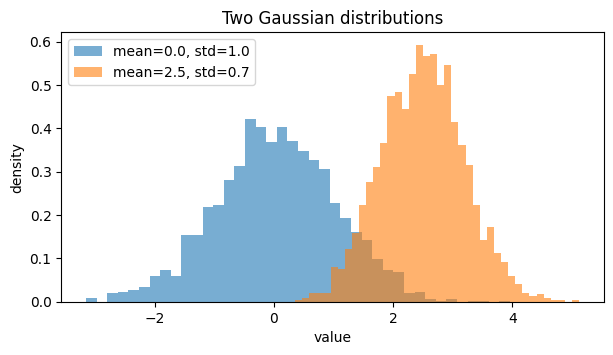

empirical mean of A: 0.033
empirical std  of A: 1.006


In [3]:
# Sample from two Gaussians and visualize
samples_a = np.random.normal(loc=0.0, scale=1.0, size=2000)
samples_b = np.random.normal(loc=2.5, scale=0.7, size=2000)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(samples_a, bins=40, alpha=0.6, density=True, label="mean=0.0, std=1.0")
ax.hist(samples_b, bins=40, alpha=0.6, density=True, label="mean=2.5, std=0.7")
ax.set_title("Two Gaussian distributions")
ax.set_xlabel("value"); ax.set_ylabel("density"); ax.legend()
plt.show()

print("empirical mean of A:", samples_a.mean().round(3))
print("empirical std  of A:", samples_a.std().round(3))

### The Gaussian formula, in code

The probability density of a value `x` under a Gaussian with mean μ and std σ has a closed
form. Implementing it once demystifies it — it's just an exponential of a squared distance.

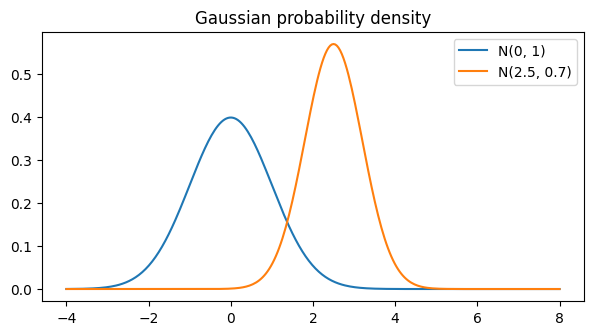

In [4]:
def gaussian_pdf(x, mu, sigma):
    coef = 1.0 / (sigma * np.sqrt(2 * np.pi))
    return coef * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

xs = np.linspace(-4, 8, 300)
plt.figure(figsize=(7, 3.5))
plt.plot(xs, gaussian_pdf(xs, 0.0, 1.0), label="N(0, 1)")
plt.plot(xs, gaussian_pdf(xs, 2.5, 0.7), label="N(2.5, 0.7)")
plt.title("Gaussian probability density"); plt.legend(); plt.show()

## 3. Maximum Likelihood Estimation (MLE)

**The core idea:** given data, pick the parameters that make the observed data *most probable*.
That single principle produces the loss functions you already know:

- Assume Gaussian noise → MLE gives you **least-squares** (mean squared error).
- Assume Bernoulli outcomes → MLE gives you **log loss / cross-entropy** (logistic regression).

Let's *see* it. We draw data from a Gaussian with an unknown mean, then compute the total
log-likelihood of the data for many candidate means. The peak lands on the sample mean —
which is exactly the maximum-likelihood estimate.

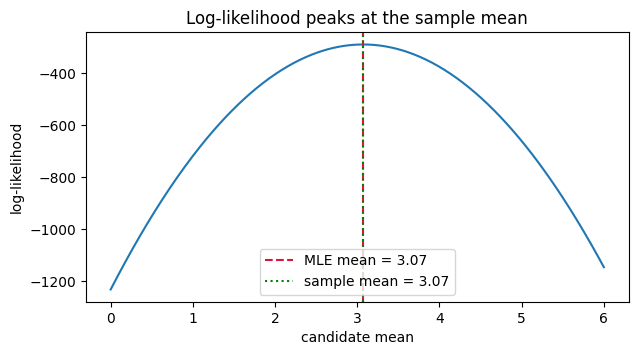

MLE and sample mean agree: True


In [5]:
true_mu, sigma = 3.0, 1.0
data = np.random.normal(true_mu, sigma, size=200)

candidate_mus = np.linspace(0, 6, 400)
# log-likelihood = sum of log-densities across all data points, for each candidate mu
log_lik = np.array([
    np.sum(np.log(gaussian_pdf(data, mu, sigma))) for mu in candidate_mus
])

best_mu = candidate_mus[np.argmax(log_lik)]

plt.figure(figsize=(7, 3.5))
plt.plot(candidate_mus, log_lik)
plt.axvline(best_mu, color="crimson", ls="--", label=f"MLE mean = {best_mu:.2f}")
plt.axvline(data.mean(), color="green", ls=":", label=f"sample mean = {data.mean():.2f}")
plt.title("Log-likelihood peaks at the sample mean")
plt.xlabel("candidate mean"); plt.ylabel("log-likelihood"); plt.legend(); plt.show()

print("MLE and sample mean agree:", np.isclose(best_mu, data.mean(), atol=0.02))

## 4. Gradient descent: how models actually learn

Most models can't be solved in one formula — instead they *iterate*: start with a guess,
measure the error, and nudge the parameters downhill along the **gradient** (the direction
of steepest increase, so we step the opposite way). Repeat until the error stops dropping.

We'll minimize a simple bowl-shaped function `f(x) = (x - 3)² + 2` whose minimum is obviously
at `x = 3`, and watch gradient descent walk there.

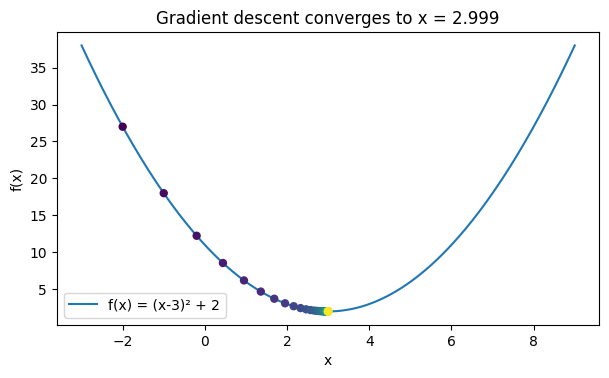

final x = 2.9993 (true minimum is 3.0)


In [6]:
def f(x):      return (x - 3) ** 2 + 2
def grad(x):   return 2 * (x - 3)      # derivative of f

x = -2.0          # starting guess
lr = 0.1          # learning rate (step size)
history = [x]
for step in range(40):
    x = x - lr * grad(x)   # the gradient-descent update
    history.append(x)

history = np.array(history)
xs = np.linspace(-3, 9, 200)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(xs, f(xs), label="f(x) = (x-3)² + 2")
ax.scatter(history, f(history), c=np.arange(len(history)), cmap="viridis", s=25, zorder=3)
ax.set_title(f"Gradient descent converges to x = {x:.3f}")
ax.set_xlabel("x"); ax.set_ylabel("f(x)"); ax.legend(); plt.show()

print(f"final x = {x:.4f} (true minimum is 3.0)")

### The learning rate is the one knob to respect

Too small → painfully slow. Too large → it overshoots and diverges. This single parameter
causes a huge share of real-world training failures, so it's worth building intuition for.

In [7]:
def run(lr, steps=15, start=-2.0):
    x, path = start, [start]
    for _ in range(steps):
        x = x - lr * grad(x); path.append(x)
    return np.array(path)

for lr in [0.01, 0.1, 0.9, 1.01]:
    path = run(lr)
    verdict = "diverges!" if abs(path[-1] - 3) > abs(path[0] - 3) else f"reaches {path[-1]:.2f}"
    print(f"lr={lr:<5} -> {verdict}")

lr=0.01  -> reaches -0.69
lr=0.1   -> reaches 2.82
lr=0.9   -> reaches 3.18
lr=1.01  -> diverges!


## Recap

- A **prediction** is a dot product `w · x + b`; matrices batch it as `X @ w`.
- **Distributions** (esp. the Gaussian) describe uncertainty with mean + spread.
- **MLE** picks parameters that make the data most likely — and *is* the origin of MSE and
  cross-entropy loss.
- **Gradient descent** fits models by stepping downhill; the **learning rate** is the knob
  that makes or breaks it.

**Next:** `03 — Linear Regression from Scratch`, where MLE + gradient descent become a real,
working model.